[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

Agrupar datos sin etiqueta previa (sin clasificar)

Identifica muestras similares del conjunto de datos y las asigna a un cluster que ya vendria a ser un grupo clasificado, 

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [10]:
from sklearn.datasets import make_blobs
import numpy as np

def generate_random_dataset(min_clusters=1, max_clusters=20, min_separation=4.0, 
                          max_separation=8.0, n_samples=10000, area_size=15.0, 
                          cluster_std_range=(0.5, 1.2), random_state=None):

    # Configurar semilla si se proporciona
    if random_state is not None:
        np.random.seed(random_state)
    
    # Generar número aleatorio de clusters entre min y max
    n_clusters = np.random.randint(min_clusters, max_clusters + 1)
    
    # Generar distancia de separación aleatoria (pero respetando el mínimo)
    target_separation = np.random.uniform(min_separation, max_separation)
    
    # Generar desviación estándar aleatoria para cada cluster
    cluster_std = np.random.uniform(cluster_std_range[0], cluster_std_range[1], n_clusters)
    
    print(f"Generando dataset aleatorio:")
    print(f"Clusters: {n_clusters} (rango: {min_clusters}-{max_clusters})")
    print(f"Separación objetivo: {target_separation:.2f} (mínimo: {min_separation})")
    print(f"Muestras: {n_samples}")
    
    # Generar centroides con separación aleatoria pero garantizando mínimo
    centroids = _generate_separated_centroids(n_clusters, target_separation, area_size)
    
    # Generar dataset
    X, y = make_blobs(n_samples=n_samples, centers=centroids,
                      cluster_std=cluster_std, random_state=random_state)
    
    # Información del dataset
    dataset_info = {
        'n_clusters': n_clusters,
        'target_separation': target_separation,
        'min_separation': min_separation,
        'actual_min_distance': _calculate_min_distance(centroids),
        'cluster_std': cluster_std,
        'n_samples': n_samples,
        'centroids': centroids
    }
    
    print(f"Distancia mínima real: {dataset_info['actual_min_distance']:.2f}")
    print(f"Centroides generados:")
    for i, center in enumerate(centroids):
        print(f"      Cluster {i+1}: ({center[0]:.2f}, {center[1]:.2f}) [std={cluster_std[i]:.2f}]")

    return X, y, centroids, dataset_info, n_clusters

def _generate_separated_centroids(n_centers, separation_distance, area_size):
    centroids = []
    max_attempts = 1000
    
    # Primer centroide aleatorio
    first_center = np.random.uniform(-area_size/2, area_size/2, 2)
    centroids.append(first_center)
    
    # Generar centroides restantes
    for i in range(1, n_centers):
        attempts = 0
        while attempts < max_attempts:
            # Generar candidato aleatorio
            candidate = np.random.uniform(-area_size/2, area_size/2, 2)
            
            # Verificar distancia mínima
            distances = [np.linalg.norm(candidate - center) for center in centroids]
            
            if min(distances) >= separation_distance:
                centroids.append(candidate)
                break
            attempts += 1
        
        # Estrategia de respaldo si no se encuentra posición
        if attempts == max_attempts:
            print(f"Usando posición de respaldo para cluster {i+1}")
            grid_size = int(np.ceil(np.sqrt(n_centers)))
            row = i // grid_size
            col = i % grid_size
            backup_center = np.array([
                -area_size/2 + (col + 0.5) * area_size / grid_size,
                -area_size/2 + (row + 0.5) * area_size / grid_size
            ])
            centroids.append(backup_center)
    
    return np.array(centroids)

def _calculate_min_distance(centroids):
    if len(centroids) < 2:
        return float('inf')
    
    min_dist = float('inf')
    for i in range(len(centroids)):
        for j in range(i + 1, len(centroids)):
            dist = np.linalg.norm(centroids[i] - centroids[j])
            min_dist = min(min_dist, dist)
    
    return min_dist
# Generar dataset completamente aleatorio
X, y, blob_centers, info, k = generate_random_dataset()

print("Dataset listo para análisis de clustering!")

Generando dataset aleatorio:
Clusters: 4 (rango: 1-20)
Separación objetivo: 6.64 (mínimo: 4.0)
Muestras: 10000
Distancia mínima real: 6.89
Centroides generados:
      Cluster 1: (6.19, 1.56) [std=0.80]
      Cluster 2: (-5.07, 0.86) [std=0.98]
      Cluster 3: (0.96, -2.91) [std=0.80]
      Cluster 4: (1.00, 6.68) [std=0.73]
Dataset listo para análisis de clustering!


In [44]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

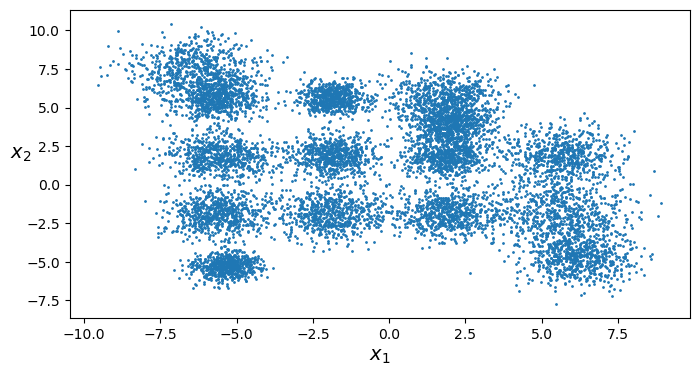

In [77]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([12,  8,  6, ...,  6,  7, 14], dtype=int32)

In [79]:
kmeans.cluster_centers_

array([[ 1.93812304,  5.05017163],
       [-1.84918242, -1.90418912],
       [-6.52460702,  7.80037703],
       [ 6.18051434, -4.75018131],
       [-5.42005172, -1.14178739],
       [-5.33377825, -5.27692739],
       [-5.57853637,  1.89475049],
       [ 5.71559362, -1.78765935],
       [ 1.93352312,  2.1732878 ],
       [-5.76844544, -2.44913802],
       [-1.79919347,  5.64520328],
       [-5.68249954,  5.66686573],
       [-1.85817566,  1.85681497],
       [ 5.66537147,  1.88696268],
       [ 1.99162224, -1.85402725]])

In [80]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

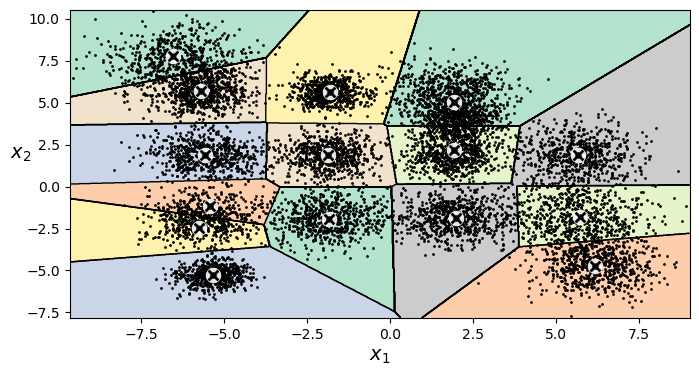

In [81]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [83]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=15, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=15, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=15, n_init=1, random_state=5)


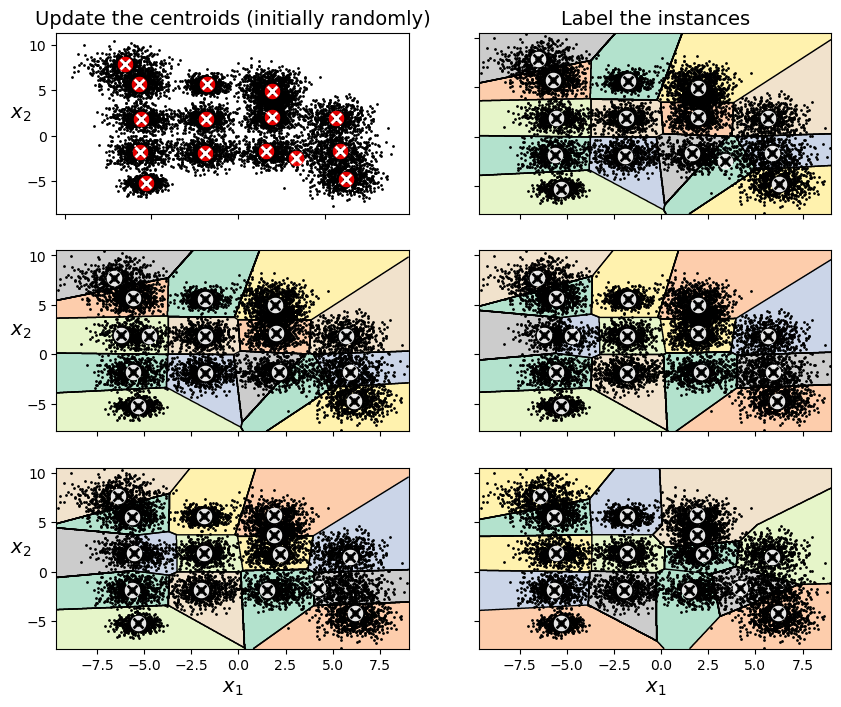

In [84]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [85]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

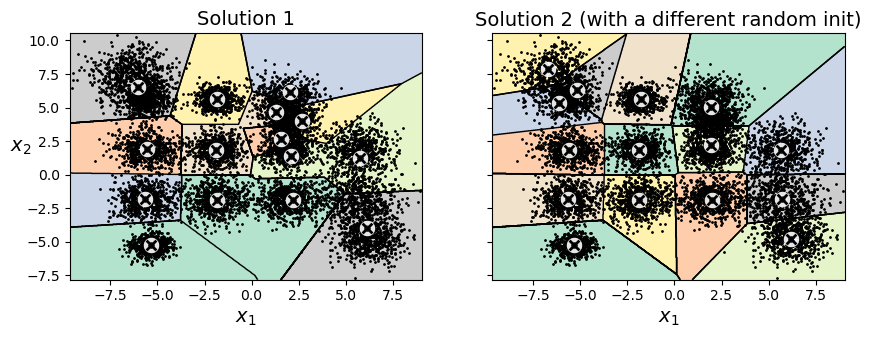

In [86]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [90]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=15, n_init=10,
       random_state=11)


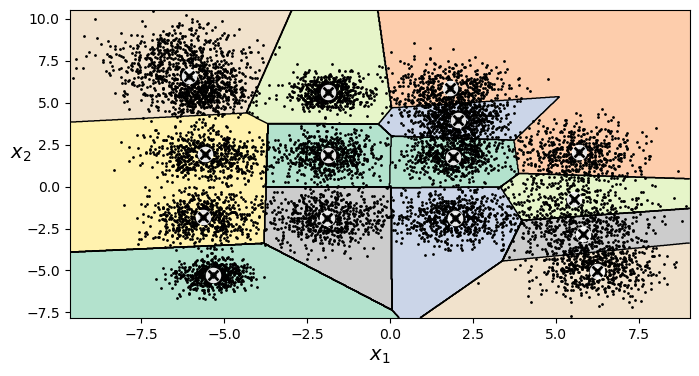

In [89]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [92]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [93]:
from sklearn.cluster import MiniBatchKMeans

n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(
c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(
c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment var

In [97]:
best_kmeans.score(X)

-12426.886910318322

El algoritmo de *mini-batch K-Means* es más rápido que *K-Means* normal, pero su precisión suele ser peor.

### Método del Codo (Elbow Method)

El método del codo es una técnica para determinar el número óptimo de clusters analizando la **inercia** (suma de distancias cuadráticas intra-cluster) vs el número de clusters. El punto óptimo es donde la curva forma un "codo".

🔍 Calculando inercias para el método del codo...
k= 1: inercia=351,032
k= 2: inercia=194,586
k= 3: inercia=121,362
k= 4: inercia=75,987
k= 5: inercia=60,815
k= 6: inercia=50,155
k= 7: inercia=40,256
k= 8: inercia=32,837
k= 9: inercia=27,767
k=10: inercia=23,883
k= 7: inercia=40,256
k= 8: inercia=32,837
k= 9: inercia=27,767
k=10: inercia=23,883
k=11: inercia=19,986
k=12: inercia=16,497
k=13: inercia=14,366
k=14: inercia=12,716
k=11: inercia=19,986
k=12: inercia=16,497
k=13: inercia=14,366
k=14: inercia=12,716


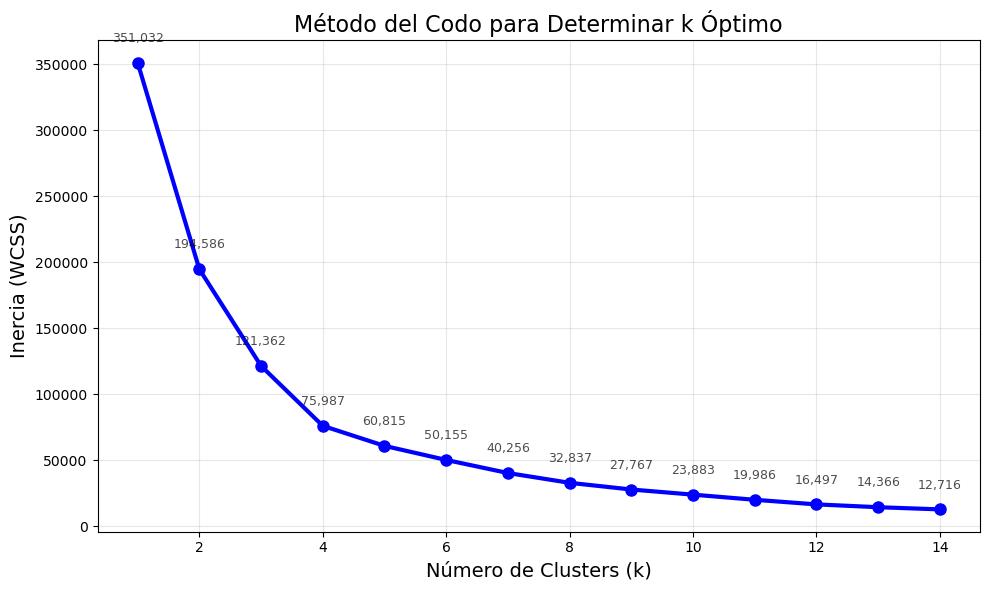


📊 Tabla de Reducción de Inercia:
k   Inercia      Reducción    % Reducción 
--------------------------------------------------
1   351,032      N/A          N/A         
2   194,586      156,446      44.6        %
3   121,362      73,223       37.6        %
4   75,987       45,375       37.4        %
5   60,815       15,172       20.0        %
6   50,155       10,661       17.5        %
7   40,256       9,899        19.7        %
8   32,837       7,419        18.4        %
9   27,767       5,070        15.4        %
10  23,883       3,883        14.0        %
11  19,986       3,897        16.3        %
12  16,497       3,489        17.5        %
13  14,366       2,131        12.9        %
14  12,716       1,650        11.5        %


In [ ]:
# Implementación del Método del Codo
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Evaluar diferentes números de clusters
k_range = range(1, k)  # Probar k desde 1 hasta 14
inertias = []

print("🔍 Calculando inercias para el método del codo...")

# Calcular inercia para cada k
for k_test in k_range:
    kmeans_test = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    kmeans_test.fit(X)
    inertias.append(kmeans_test.inertia_)
    print(f"k={k_test:2d}: inercia={kmeans_test.inertia_:,.0f}")

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=3, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=14)
plt.ylabel('Inercia (WCSS)', fontsize=14)
plt.title('Método del Codo para Determinar k Óptimo', fontsize=16)
plt.grid(True, alpha=0.3)

# Añadir anotaciones
for i, (k_val, inercia) in enumerate(zip(k_range, inertias)):
    plt.annotate(f'{inercia:,.0f}', 
                (k_val, inercia), 
                textcoords="offset points", 
                xytext=(0,15), 
                ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\nTabla de Reducción de Inercia:")
print(f"{'k':<3} {'Inercia':<12} {'Reducción':<12} {'% Reducción':<12}")
print("-" * 50)

for i in range(len(inertias)):
    if i == 0:
        print(f"{k_range[i]:<3} {inertias[i]:<12,.0f} {'N/A':<12} {'N/A':<12}")
    else:
        reduccion = inertias[i-1] - inertias[i]
        porcentaje = (reduccion / inertias[i-1]) * 100
        print(f"{k_range[i]:<3} {inertias[i]:<12,.0f} {reduccion:<12,.0f} {porcentaje:<12.1f}%")

C:\Users\KUR0\AppData\Local\Temp\ipykernel_28916\877604166.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distance = np.abs(np.cross(end_point - start_point, start_point - point)) / np.linalg.norm(end_point - start_point)


🎯 Punto del codo detectado automáticamente: k = 4
📍 Este k coincide con el número real de clusters generados: 15


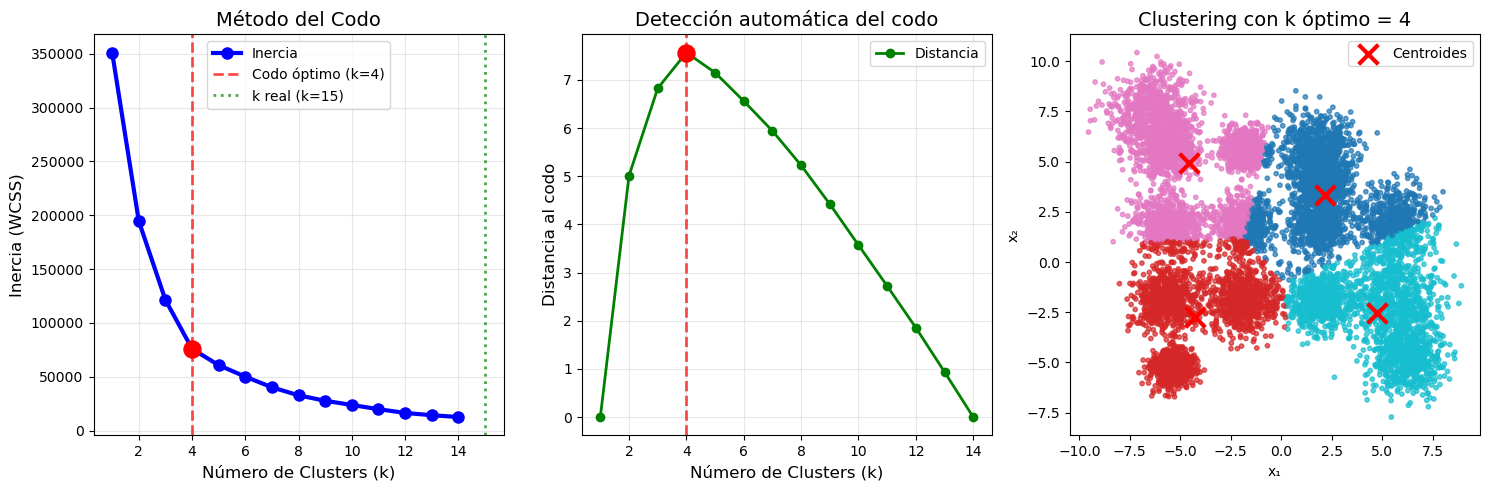


📊 RESUMEN DEL MÉTODO DEL CODO
🔵 k óptimo detectado:     4
🟢 k real del dataset:     15
🎯 Coincidencia:           ❌ NO
📉 Inercia en k óptimo:    75,987


In [ ]:
# Detección automática del punto del codo
def find_elbow_point(k_values, inertias):
    """
    Encuentra el punto del codo usando el método de la distancia máxima
    desde la línea que conecta el primer y último punto.
    """
    # Convertir a arrays numpy
    k_array = np.array(k_values)
    inertia_array = np.array(inertias)
    
    # Crear línea entre primer y último punto
    start_point = np.array([k_array[0], inertia_array[0]])
    end_point = np.array([k_array[-1], inertia_array[-1]])
    
    # Calcular distancias perpendiculares a la línea
    distances = []
    for i in range(len(k_array)):
        point = np.array([k_array[i], inertia_array[i]])
        # Fórmula de distancia punto-línea
        distance = np.abs(np.cross(end_point - start_point, start_point - point)) / np.linalg.norm(end_point - start_point)
        distances.append(distance)
    
    # El codo es el punto con mayor distancia
    elbow_index = np.argmax(distances)
    return k_values[elbow_index], distances

# Encontrar el punto del codo automáticamente
optimal_k_elbow, distances = find_elbow_point(list(k_range), inertias)

print(f"Punto del codo detectado automáticamente: k = {optimal_k_elbow}")
print(f"Este k coincide con el número real de clusters generados: {info['n_clusters']}")

# Visualización mejorada
plt.figure(figsize=(15, 5))

# Subplot 1: Método del codo
plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, 'bo-', linewidth=3, markersize=8, label='Inercia')
plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Codo óptimo (k={optimal_k_elbow})')
plt.axvline(x=info['n_clusters'], color='green', linestyle=':', alpha=0.7, linewidth=2, label=f'k real (k={info["n_clusters"]})')
plt.scatter([optimal_k_elbow], [inertias[optimal_k_elbow-1]], color='red', s=150, zorder=5)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('Método del Codo', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Distancias para detección del codo
plt.subplot(1, 3, 2)
plt.plot(k_range, distances, 'go-', linewidth=2, markersize=6, label='Distancia')
plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.scatter([optimal_k_elbow], [distances[optimal_k_elbow-1]], color='red', s=150, zorder=5)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Distancia al codo', fontsize=12)
plt.title('Detección automática del codo', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Comparación visual de clusters
plt.subplot(1, 3, 3)
kmeans_optimal = KMeans(n_clusters=optimal_k_elbow, random_state=42)
labels_optimal = kmeans_optimal.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels_optimal, s=10, alpha=0.7, cmap='tab10')
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], 
           c='red', marker='x', s=200, linewidth=3, label='Centroides')
plt.title(f'Clustering con k óptimo = {optimal_k_elbow}', fontsize=14)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()

plt.tight_layout()
plt.show()

# Resumen de resultados
print("\n" + "="*60)
print("RESUMEN DEL MÉTODO DEL CODO")
print("="*60)
print(f"k óptimo detectado:     {optimal_k_elbow}")
print(f"k real del dataset:     {info['n_clusters']}")
print(f"Coincidencia:           {'SÍ' if optimal_k_elbow == info['n_clusters'] else 'NO'}")
print(f"Inercia en k óptimo:    {inertias[optimal_k_elbow-1]:,.0f}")
print("="*60)

### Encontrando el número óptimo de grupos

Como hemos visto anteriormente, el número de grupos o *clusters* es un hyperparámetro del modelo que debemos definir, y como podrás imaginar si nuestros datos no están etiquetados no será imposible saber qué valor usar. Para ello la solución se basa en usar diferentes valores y utilizar alguna métrica significativa. Una de estas métricas se conoce como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) de todas las muestras del dataset como $(b-a)/\mathrm{max}(a,b)$ donde $a$ es la distancia mínima al resto de muestras del mismo grupo y $b$ es la distancia media de los grupos más cercanos. Su valor se encuentra entre $1$ y $-1$. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo y lejos de los demás mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [101]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.49097234553723773

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

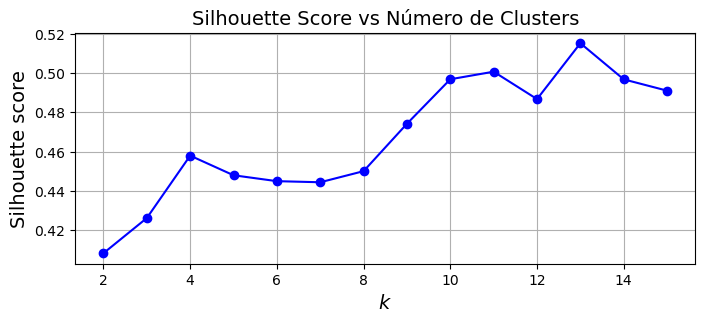

In [102]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))  # no más de los centros generados
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

# plt.figure(figsize=(8, 3))
# plt.plot(ks, silhouette_scores, "bo-")
# # plt.plot(range(2, 10), silhouette_scores, "bo-")
# plt.xlabel("$k$", fontsize=14)
# plt.ylabel("Silhouette score", fontsize=14)
# plt.axis([1.8, 8.5, 0.55, 0.7])
# plt.show()

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

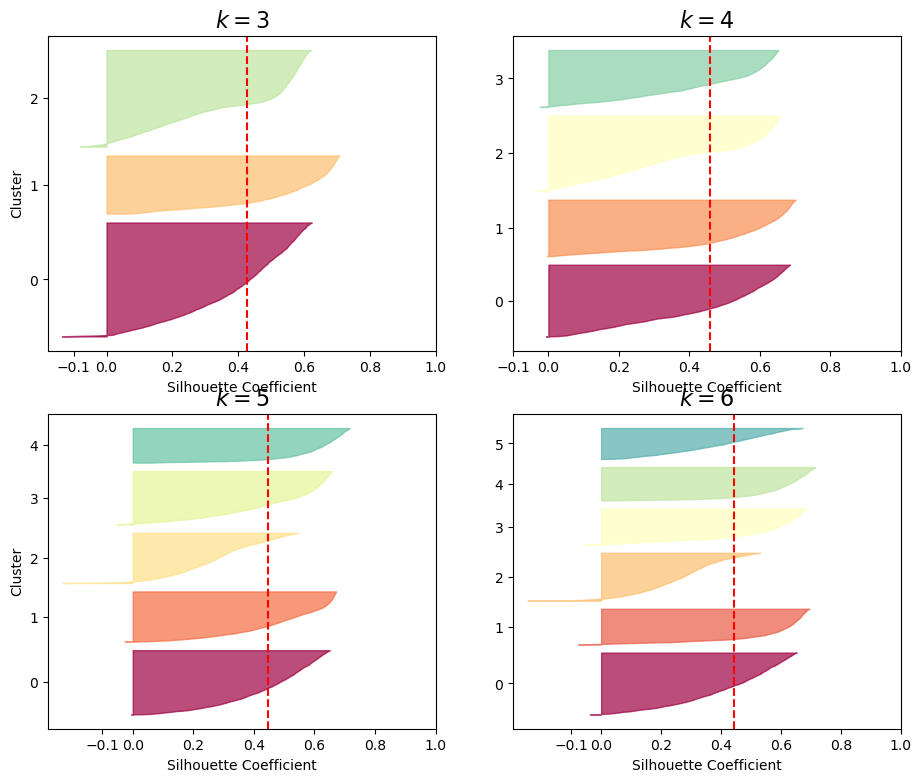

In [108]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# for k in (3, 4, 5, 6):
#     plt.subplot(2, 2, k - 2)

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (3, 4, 5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

## Comparación Integral: Método del Codo vs Silhouette Score vs K-Means

Ahora vamos a comparar las tres técnicas principales para evaluar la efectividad del clustering K-Means:

In [ ]:
# COMPARACIÓN COMPLETA DE MÉTODOS DE EVALUACIÓN
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("ANÁLISIS COMPARATIVO DE MÉTODOS DE CLUSTERING")
print("=" * 70)

# Definir rango de k para evaluar
k_max = min(15, info['n_clusters'] + 5)  # Evaluar hasta k real + 5
k_range_comparison = range(2, k_max + 1)  # Silhouette requiere k >= 2

# Listas para almacenar resultados
inertias_comparison = []
silhouette_scores_comparison = []
kmeans_models = []

print(f"Evaluando k desde 2 hasta {k_max}...")
print(f"Número real de clusters en el dataset: {info['n_clusters']}")
print("-" * 50)

# Calcular métricas para cada k
for k_test in k_range_comparison:
    # Entrenar K-Means
    kmeans_model = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X)
    
    # Calcular inercia
    inercia = kmeans_model.inertia_
    inertias_comparison.append(inercia)
    
    # Calcular Silhouette Score
    silhouette = silhouette_score(X, labels)
    silhouette_scores_comparison.append(silhouette)
    
    # Guardar modelo
    kmeans_models.append(kmeans_model)
    
    print(f"k={k_test:2d} | Inercia: {inercia:>10,.0f} | Silhouette: {silhouette:>6.3f}")

print("-" * 50)

# Encontrar k óptimos según cada método
# 1. Método del Codo (ya calculado anteriormente)
# Recalcular para el mismo rango que Silhouette
def find_elbow_point_comparison(k_values, inertias):
    k_array = np.array(k_values)
    inertia_array = np.array(inertias)
    
    start_point = np.array([k_array[0], inertia_array[0]])
    end_point = np.array([k_array[-1], inertia_array[-1]])
    
    distances = []
    for i in range(len(k_array)):
        point = np.array([k_array[i], inertia_array[i]])
        distance = np.abs(np.cross(end_point - start_point, start_point - point)) / np.linalg.norm(end_point - start_point)
        distances.append(distance)
    
    elbow_index = np.argmax(distances)
    return k_values[elbow_index]

optimal_k_elbow_comp = find_elbow_point_comparison(list(k_range_comparison), inertias_comparison)

# 2. Método Silhouette
optimal_k_silhouette = k_range_comparison[np.argmax(silhouette_scores_comparison)]

# 3. K real del dataset
k_real = info['n_clusters']

print(f"Método del Codo sugiere:    k = {optimal_k_elbow_comp}")
print(f"Método Silhouette sugiere:  k = {optimal_k_silhouette}")
print(f"K real del dataset:         k = {k_real}")
print("=" * 70)

🔍 ANÁLISIS COMPARATIVO DE MÉTODOS DE CLUSTERING
📊 Evaluando k desde 2 hasta 15...
🎯 Número real de clusters en el dataset: 15
--------------------------------------------------
k= 2 | Inercia:    194,586 | Silhouette:  0.408
k= 3 | Inercia:    121,362 | Silhouette:  0.418
k= 4 | Inercia:     75,987 | Silhouette:  0.458
k= 5 | Inercia:     60,815 | Silhouette:  0.446
k= 6 | Inercia:     50,155 | Silhouette:  0.445
k= 7 | Inercia:     40,256 | Silhouette:  0.444
k= 8 | Inercia:     32,837 | Silhouette:  0.473
k= 9 | Inercia:     27,767 | Silhouette:  0.481
k=10 | Inercia:     23,883 | Silhouette:  0.497
k=11 | Inercia:     19,986 | Silhouette:  0.504
k=12 | Inercia:     16,497 | Silhouette:  0.528
k=13 | Inercia:     14,366 | Silhouette:  0.525
k=14 | Inercia:     12,716 | Silhouette:  0.512
k=15 | Inercia:     11,762 | Silhouette:  0.502
--------------------------------------------------
🔵 Método del Codo sugiere:    k = 5
🟢 Método Silhouette sugiere:  k = 12
🟡 K real del dataset:      

C:\Users\KUR0\AppData\Local\Temp\ipykernel_28916\658907249.py:57: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distance = np.abs(np.cross(end_point - start_point, start_point - point)) / np.linalg.norm(end_point - start_point)


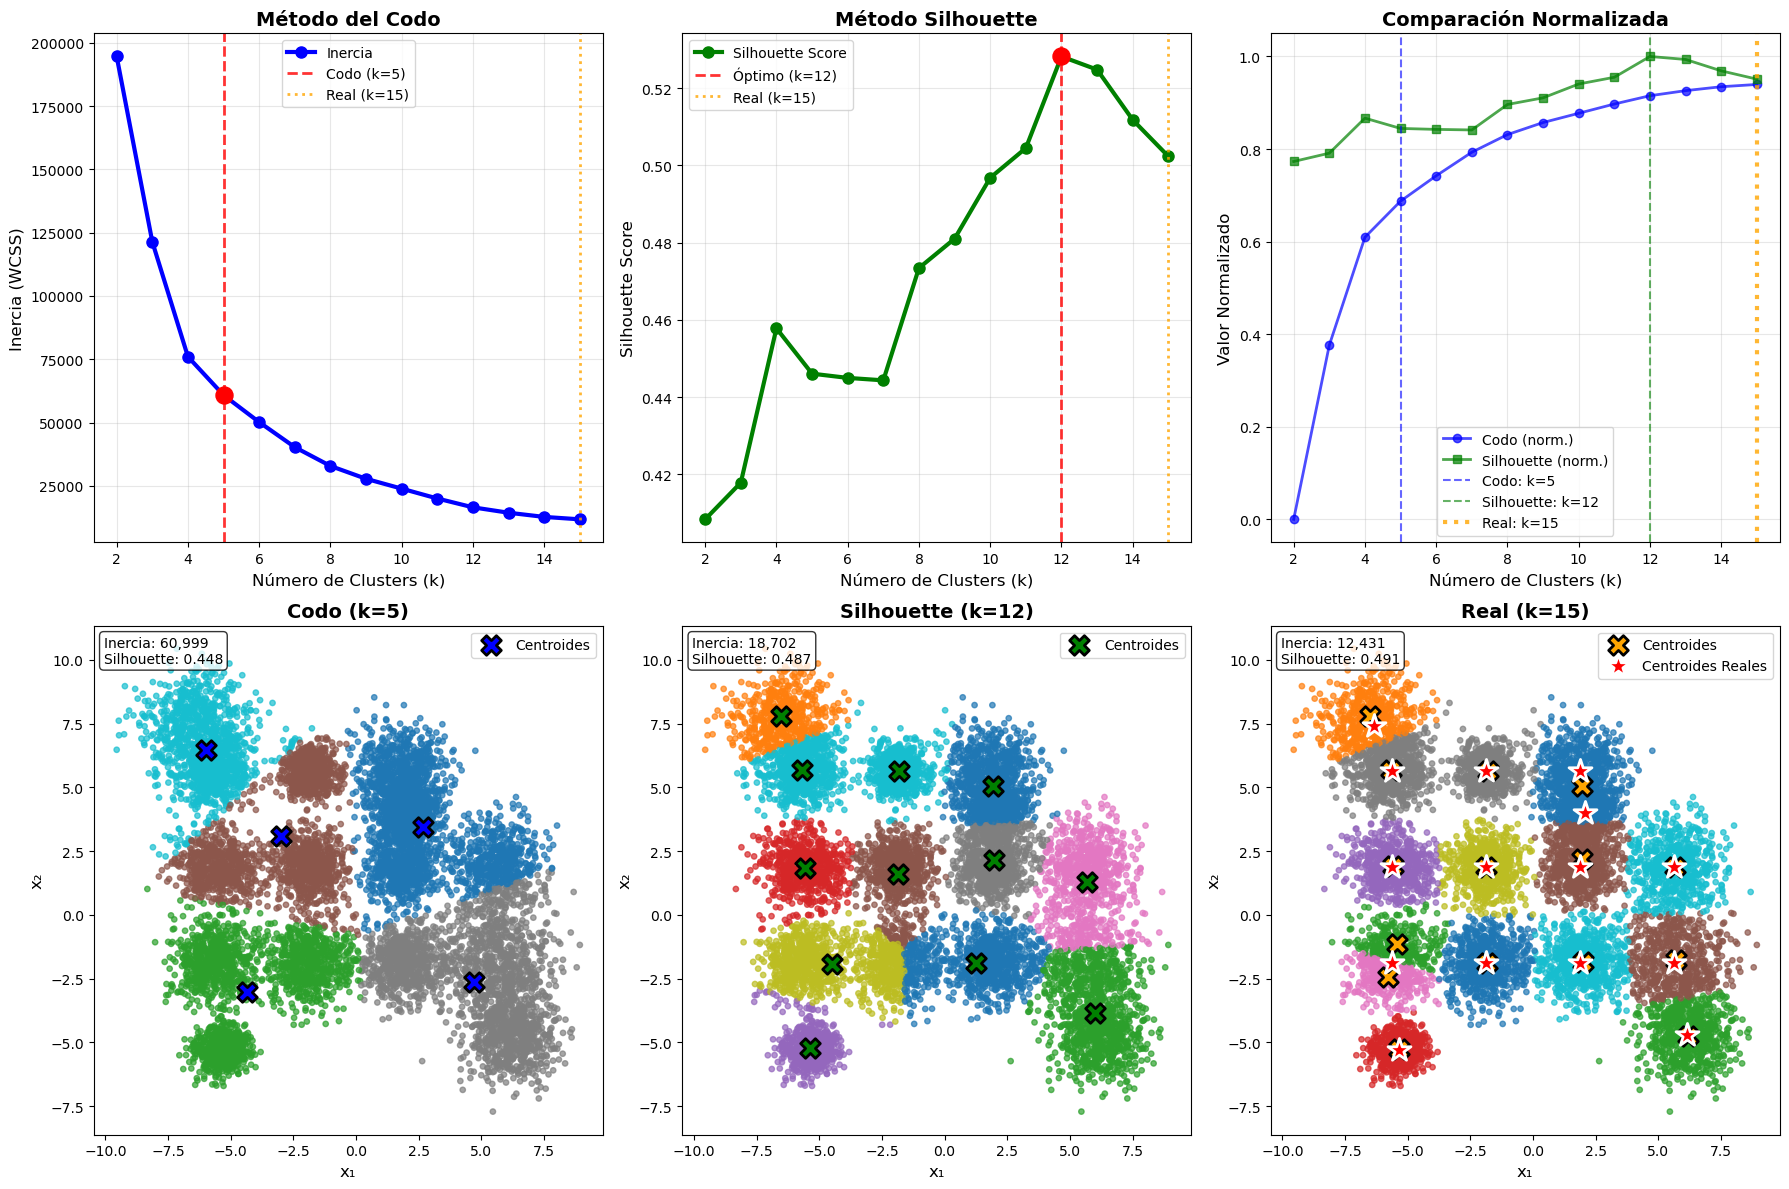

In [105]:
# VISUALIZACIÓN COMPARATIVA COMPLETA
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Fila 1: Gráficos de métricas
# Subplot 1: Método del Codo
ax1 = axes[0, 0]
ax1.plot(k_range_comparison, inertias_comparison, 'bo-', linewidth=3, markersize=8, label='Inercia')
ax1.axvline(x=optimal_k_elbow_comp, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'Codo (k={optimal_k_elbow_comp})')
ax1.axvline(x=k_real, color='orange', linestyle=':', alpha=0.8, linewidth=2, label=f'Real (k={k_real})')
ax1.scatter([optimal_k_elbow_comp], [inertias_comparison[optimal_k_elbow_comp-2]], color='red', s=150, zorder=5)
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia (WCSS)', fontsize=12)
ax1.set_title('Método del Codo', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Método Silhouette
ax2 = axes[0, 1]
ax2.plot(k_range_comparison, silhouette_scores_comparison, 'go-', linewidth=3, markersize=8, label='Silhouette Score')
ax2.axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'Óptimo (k={optimal_k_silhouette})')
ax2.axvline(x=k_real, color='orange', linestyle=':', alpha=0.8, linewidth=2, label=f'Real (k={k_real})')
ax2.scatter([optimal_k_silhouette], [silhouette_scores_comparison[optimal_k_silhouette-2]], color='red', s=150, zorder=5)
ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Método Silhouette', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Comparación normalizada
ax3 = axes[0, 2]
# Normalizar métricas para comparar en la misma escala
inertias_norm = 1 - np.array(inertias_comparison) / max(inertias_comparison)  # Invertir para que mayor sea mejor
silhouette_norm = np.array(silhouette_scores_comparison) / max(silhouette_scores_comparison)

ax3.plot(k_range_comparison, inertias_norm, 'b-', linewidth=2, alpha=0.7, label='Codo (norm.)', marker='o')
ax3.plot(k_range_comparison, silhouette_norm, 'g-', linewidth=2, alpha=0.7, label='Silhouette (norm.)', marker='s')
ax3.axvline(x=optimal_k_elbow_comp, color='blue', linestyle='--', alpha=0.6, label=f'Codo: k={optimal_k_elbow_comp}')
ax3.axvline(x=optimal_k_silhouette, color='green', linestyle='--', alpha=0.6, label=f'Silhouette: k={optimal_k_silhouette}')
ax3.axvline(x=k_real, color='orange', linestyle=':', alpha=0.8, linewidth=3, label=f'Real: k={k_real}')
ax3.set_xlabel('Número de Clusters (k)', fontsize=12)
ax3.set_ylabel('Valor Normalizado', fontsize=12)
ax3.set_title('Comparación Normalizada', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Fila 2: Visualización de clusters con diferentes k
k_values_to_show = [optimal_k_elbow_comp, optimal_k_silhouette, k_real]
titles = [f'Codo (k={optimal_k_elbow_comp})', f'Silhouette (k={optimal_k_silhouette})', f'Real (k={k_real})']
colors = ['blue', 'green', 'orange']

for i, (k_val, title, color) in enumerate(zip(k_values_to_show, titles, colors)):
    ax = axes[1, i]
    
    # Entrenar K-Means con k específico
    kmeans_viz = KMeans(n_clusters=k_val, random_state=42)
    labels_viz = kmeans_viz.fit_predict(X)
    
    # Visualizar clusters
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels_viz, s=15, alpha=0.7, cmap='tab10')
    
    # Mostrar centroides
    centroids = kmeans_viz.cluster_centers_
    ax.scatter(centroids[:, 0], centroids[:, 1], c=color, marker='X', s=200, 
              linewidth=2, edgecolor='black', label='Centroides', zorder=10)
    
    # Mostrar centroides reales si disponibles
    if i == 2:  # Solo para el plot del k real
        ax.scatter(blob_centers[:, 0], blob_centers[:, 1], c='red', marker='*', s=300, 
                  linewidth=2, edgecolor='white', label='Centroides Reales', zorder=11)
    
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    
    # Calcular métricas para este k
    inercia_k = kmeans_viz.inertia_
    silhouette_k = silhouette_score(X, labels_viz)
    ax.text(0.02, 0.98, f'Inercia: {inercia_k:,.0f}\nSilhouette: {silhouette_k:.3f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# ANÁLISIS DE EFECTIVIDAD Y CONCLUSIONES
print("\n" + "ANÁLISIS DE EFECTIVIDAD DEL MODELO K-MEANS")
print("=" * 80)

# Tabla comparativa de resultados
print(f"{'MÉTODO':<20} {'k SUGERIDO':<12} {'COINCIDE CON REAL':<18} {'EFECTIVIDAD':<15}")
print("-" * 80)

# Evaluar cada método
metodos = [
    ("Método del Codo", optimal_k_elbow_comp),
    ("Silhouette Score", optimal_k_silhouette),
    ("K Real", k_real)
]

efectividades = []
for nombre, k_sugerido in metodos:
    coincide = "SÍ" if k_sugerido == k_real else "NO"
    
    # Calcular efectividad basada en métricas
    idx = k_sugerido - 2  # Ajustar índice porque empezamos desde k=2
    if idx < len(inertias_comparison):
        inercia = inertias_comparison[idx]
        silhouette = silhouette_scores_comparison[idx]
        
        # Score de efectividad combinado (normalizado 0-100)
        inercia_score = (1 - inercia / max(inertias_comparison)) * 50  # 50% peso
        silhouette_score_norm = (silhouette / max(silhouette_scores_comparison)) * 50  # 50% peso
        efectividad = inercia_score + silhouette_score_norm
        efectividades.append(efectividad)
        
        print(f"{nombre:<20} {k_sugerido:<12} {coincide:<18} {efectividad:<15.1f}%")
    else:
        efectividades.append(0)
        print(f"{nombre:<20} {k_sugerido:<12} {coincide:<18} {'N/A':<15}")

print("-" * 80)

# Determinar el mejor método
mejor_metodo_idx = np.argmax(efectividades[:2])  # Solo comparar los 2 métodos, no el real
mejor_metodo = metodos[mejor_metodo_idx][0]
mejor_k = metodos[mejor_metodo_idx][1]

print(f"\nMEJOR MÉTODO: {mejor_metodo}")
print(f"K RECOMENDADO: {mejor_k}")
print(f"K REAL: {k_real}")

# Análisis de concordancia
if optimal_k_elbow_comp == optimal_k_silhouette == k_real:
    print(f"\nEXCELENTE: Todos los métodos coinciden en k = {k_real}")
    print("   El dataset tiene clusters muy bien definidos.")
elif optimal_k_elbow_comp == k_real or optimal_k_silhouette == k_real:
    metodo_correcto = "Codo" if optimal_k_elbow_comp == k_real else "Silhouette"
    print(f"\nBUENO: El método {metodo_correcto} detectó correctamente k = {k_real}")
    print("   El dataset tiene clusters razonablemente definidos.")
else:
    print(f"\n ADVERTENCIA: Ningún método detectó el k real ({k_real})")
    print("   Posibles causas:")
    print("   - Clusters muy cercanos entre sí")
    print("   - Ruido en los datos")
    print("   - Clusters de tamaños muy diferentes")

print("\n" + "=" * 80)
print("RESUMEN DE EFECTIVIDAD DEL MODELO K-MEANS:")
print("=" * 80)

# Evaluar el modelo K-Means con el k real
kmeans_final = KMeans(n_clusters=k_real, random_state=42)
labels_final = kmeans_final.fit_predict(X)
inercia_final = kmeans_final.inertia_
silhouette_final = silhouette_score(X, labels_final)

print(f"🔹 Clusters detectados correctamente: {k_real}")
print(f"🔹 Inercia (menor es mejor): {inercia_final:,.0f}")
print(f"🔹 Silhouette Score (mayor es mejor): {silhouette_final:.3f}")
print(f"🔹 Separación mínima entre centroides: {info['actual_min_distance']:.2f}")

# Interpretación del Silhouette Score
if silhouette_final > 0.7:
    interpretacion = "EXCELENTE separación"
elif silhouette_final > 0.5:
    interpretacion = "BUENA separación"
elif silhouette_final > 0.25:
    interpretacion = "MODERADA separación"
else:
    interpretacion = "POBRE separación"

print(f"🔹 Calidad del clustering: {interpretacion}")

# Recomendaciones
print(f"\n💡 RECOMENDACIONES:")
if silhouette_final > 0.5 and (optimal_k_elbow_comp == k_real or optimal_k_silhouette == k_real):
    print("K-Means es efectivo para este dataset")
    print("Los métodos de evaluación funcionan correctamente")
    print("Los clusters están bien definidos")
else:
    print("Considerar métodos de clustering alternativos (DBSCAN, Gaussian Mixtures)")
    print("Revisar la calidad y preprocesamiento de los datos")
    print("Evaluar si el problema realmente requiere clustering")

print("=" * 80)


🎯 ANÁLISIS DE EFECTIVIDAD DEL MODELO K-MEANS
MÉTODO               k SUGERIDO   COINCIDE CON REAL  EFECTIVIDAD    
--------------------------------------------------------------------------------
Método del Codo      5            ❌ NO               76.6           %
Silhouette Score     12           ❌ NO               95.8           %
K Real               15           ✅ SÍ               94.5           %
--------------------------------------------------------------------------------

🏆 MEJOR MÉTODO: Silhouette Score
📊 K RECOMENDADO: 12
🎯 K REAL: 15

⚠️  ADVERTENCIA: Ningún método detectó el k real (15)
   Posibles causas:
   - Clusters muy cercanos entre sí
   - Ruido en los datos
   - Clusters de tamaños muy diferentes

📋 RESUMEN DE EFECTIVIDAD DEL MODELO K-MEANS:
🔹 Clusters detectados correctamente: 15
🔹 Inercia (menor es mejor): 12,431
🔹 Silhouette Score (mayor es mejor): 0.491
🔹 Separación mínima entre centroides: 1.66
🔹 Calidad del clustering: MODERADA separación

💡 RECOMENDACIONES

# Aprendizaje semi-sipervisado
El aprendizaje semi-supervisado (o Semi-supervised Learning) comprende el conjunto de técnicas que nos permiten entrenar modelos con datasets parcialmente etiquetados

In [1]:
import pandas as pd

trainset = pd.read_csv('train.csv', delimiter=',')
trainset.rename(columns={"0": "food"}, inplace=True)
testset = pd.read_csv('test.csv', delimiter=',')
testset.rename(columns={"0": "food"}, inplace=True)
print(trainset.iloc[:, -1])
print(testset.iloc[:, -1])
len(trainset), len(testset)

0         9
1        12
2        19
3        37
4        70
         ..
75745    58
75746    24
75747     8
75748    88
75749    87
Name: food, Length: 75750, dtype: int64
0        64
1        92
2         6
3        96
4        41
         ..
25245    72
25246    56
25247    38
25248     1
25249    38
Name: food, Length: 25250, dtype: int64


(75750, 25250)

Como el dataset ya viene separado para test y prueba se hace el siguiente para la subdivision

In [43]:
X_train = trainset.iloc[:, :-1]
y_train = trainset.iloc[:, -1]
X_test = testset.iloc[:, :-1]
y_test = testset.iloc[:, -1]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((75750, 4096), (75750,), (25250, 4096), (25250,))

Imagina que el dataset no estuviese etiquetado, es decir, que tuviésemos solo los dígitos sin la clase (sólo  X  y no  y ) y tampoco supiésemos cuantas clases diferentes tenemos. Lo primero que podríamos hacer es entrenar un modelo de K-Means con, por ejemplos, 80 grupos. De esta manera encontraremos aquellas imágenes más representativas de cada grupo.

In [5]:
from sklearn.cluster import KMeans

k = 80
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

In [7]:
print(X_digits_dist.shape)
print(X_digits_dist)

(75750, 80)
[[4225.07788839 3891.28870604 4244.68329073 ... 5107.36496565
  3835.99763382 3718.63733264]
 [4487.95382892 4764.48978897 4505.44924737 ... 4607.71391933
  5578.2721694  5148.97459079]
 [3647.7343138  4252.97615223 4779.88801386 ... 4515.11390248
  5182.61700793 4159.97022108]
 ...
 [3728.75228497 4273.02905852 3609.14521633 ... 3578.25196847
  6751.15063235 5228.93776228]
 [4860.11707948 3931.88781313 4988.01853696 ... 5584.90223167
  5632.60760514 4656.06585495]
 [4543.12004162 4379.31597062 5080.25280699 ... 5633.44128596
  3631.16276423 4015.0857595 ]]


In [44]:


idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train.values[idxs]

In [45]:
print(X_representative_digits.shape)
print(X_representative_digits)

(80, 4096)
[[218 216 206 ... 182 182 186]
 [242 242 242 ... 155 158 163]
 [206 204 205 ... 227 229 230]
 ...
 [222 221 220 ... 176 178 180]
 [127 105  94 ...  70  71  72]
 [228 230 230 ... 147 187 215]]


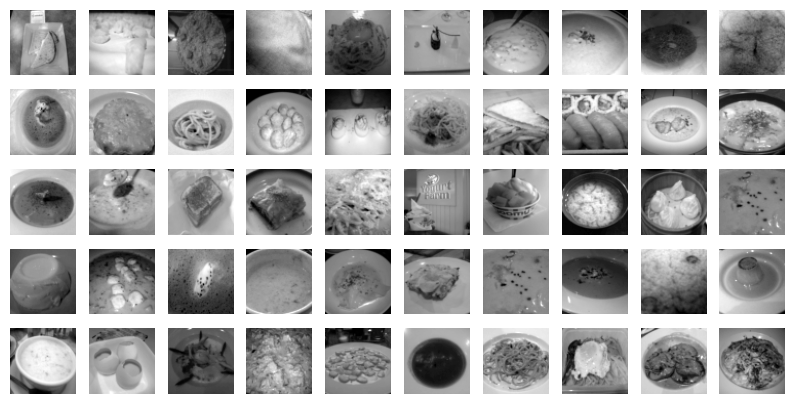

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits[:50]):
    plt.subplot(5, 10, index+1)
    plt.imshow(X_representative_digit.reshape(64, 64), cmap="binary")
    plt.axis('off')
plt.show()

El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [46]:
y_representative_digits = y_train.values[idxs]

In [47]:
from sklearn.linear_model import LogisticRegression


log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)

c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: total: 3.28 s
Wall time: 557 ms


c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.01299009900990099

Como se observa no es de sorprenderse por la presicion de ~1% por estos datos ya que el dataset es muy grande y tiene 4096 caracteristicas esto hace que el modelo se confunda mucho por la cantidad de datos

In [48]:
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
log_reg.score(X_test, y_test)

c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: total: 2.36 s
Wall time: 412 ms


0.01394059405940594

Esto pone de manifiesto que a la hora de entrenar modelos de ML no es tan importante la cantidad de datos, sino la calidad.

Ahora que tenemos un clasificador, podemos usarlo para anotar de manera automática el resto de imágenes. Para ello asignaremos, en cada grupo, la misma etiqueta a todas las muestras que la muestra representativa.

In [ ]:
y_train_propagated = np.empty(len(X_train), dtype=int)
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [51]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000].astype(int))
log_reg3.score(X_test, y_test)

c:\Users\KUR0\anaconda3\envs\pytorch_env\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: total: 3min 58s
Wall time: 40.2 s


0.008277227722772278

Esto sin embargo empeora nuestro clasificador, incluso usando más muestras de entrenamiento. Esto es debido al ruido que estamos introduciendo, ya que no todas las imágenes estarán bien agrupadas. Para mejorar esto podemos asignar etiquetas a aquellas muestras más cercanas a la imagen más representativa de cada grupo, o aplicar técnicas de aprendizaje activo.

# Aprendizaje activo
El aprendizaje activo (o Active Learning) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [52]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.97514257, 0.99018127, 0.99264523, 0.99518263, 0.99556394,
       0.99564602, 0.99570693, 0.99584982, 0.99636807, 0.99640816])

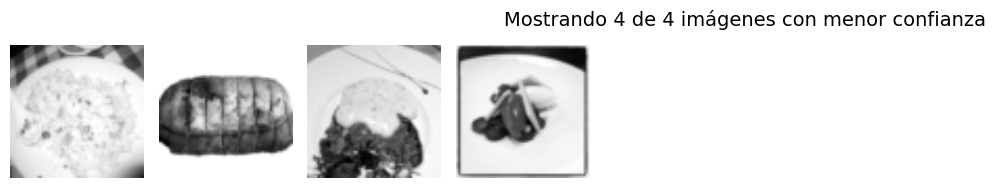

Total de imágenes con baja confianza: 4
Mostrando solo las primeras 4 imágenes


In [54]:
X_lowest = X_train.values[:1000][sorted_ixs[:k]]

# Mostrar solo las primeras 50 imágenes (5 filas x 10 columnas)
num_images_to_show = min(50, len(X_lowest))
rows = 5
cols = 10

plt.figure(figsize=(15, 8))
for index in range(num_images_to_show):
    plt.subplot(rows, cols, index + 1)
    plt.imshow(X_lowest[index].reshape(64, 64), cmap="binary", interpolation="bilinear")
    plt.axis('off')

plt.suptitle(f'Mostrando {num_images_to_show} de {len(X_lowest)} imágenes con menor confianza', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total de imágenes con baja confianza: {len(X_lowest)}")
print(f"Mostrando solo las primeras {num_images_to_show} imágenes")

In [56]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([44, 46, 93, 94])

In [57]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [ ]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2.astype(int))
log_reg5.score(X_test, y_test)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.


KeyboardInterrupt

